In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARREGAMENTO E TRADUÇÃO (DATA CLEANING)


# Carregando o arquivo original
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Spotify/dataset.csv')


traducao_colunas = {
    'track_name': 'nome_da_musica',
    'artists': 'artistas',
    'album_name': 'nome_do_album',
    'popularity': 'popularidade',
    'duration_ms': 'duracao_ms',
    'danceability': 'dancibilidade',
    'energy': 'energia',
    'loudness': 'volume',
    'speechiness': 'presenca_de_fala',
    'acousticness': 'acustica',
    'instrumentalness': 'instrumentalidade',
    'liveness': 'ao_vivo',
    'valence': 'valencia',
    'tempo': 'ritmo_bpm',
    'track_genre': 'genero'
}

# Renomeando as colunas no DataFrame
df = df.rename(columns=traducao_colunas)

# Limpeza básica: removendo nulos e duplicatas
df = df.dropna()
df = df.drop_duplicates(subset=['track_id'])

In [33]:
# 2. TRANSFORMAÇÃO

# Criando a coluna de duração em minutos
df['duracao_minutos'] = df['duracao_ms'] / 60000

# Criando a classificação de "Hit"
df['eh_hit'] = df['popularidade'].apply(lambda x: 'Hit (>80)' if x > 80 else 'Normal')

# Configuração visual
sns.set_theme(style="whitegrid")

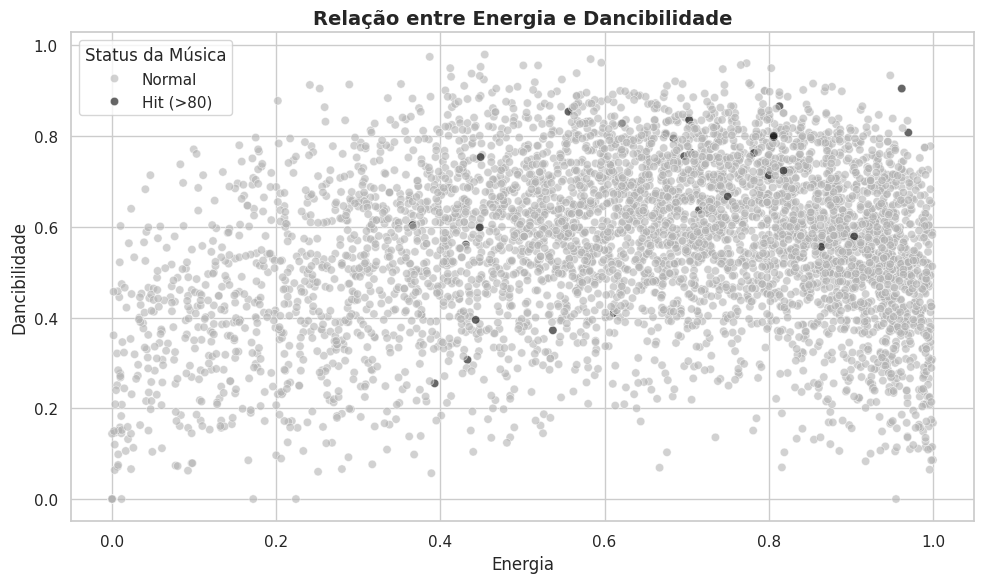

In [34]:
# 3. GRÁFICO 1: Energia vs Dancibilidade

plt.figure(figsize=(10, 6))
df_amostra = df.sample(n=5000, random_state=42)

sns.scatterplot(
    data=df_amostra,
    x='energia',
    y='dancibilidade',
    hue='eh_hit',
    palette={'Hit (>80)': 'black', 'Normal': '#B3B3B3'},
    alpha=0.6
)
plt.title('Relação entre Energia e Dancibilidade', fontsize=14, fontweight='bold')
plt.xlabel('Energia', fontsize=12)
plt.ylabel('Dancibilidade', fontsize=12)
plt.legend(title='Status da Música')
plt.tight_layout()
plt.show()

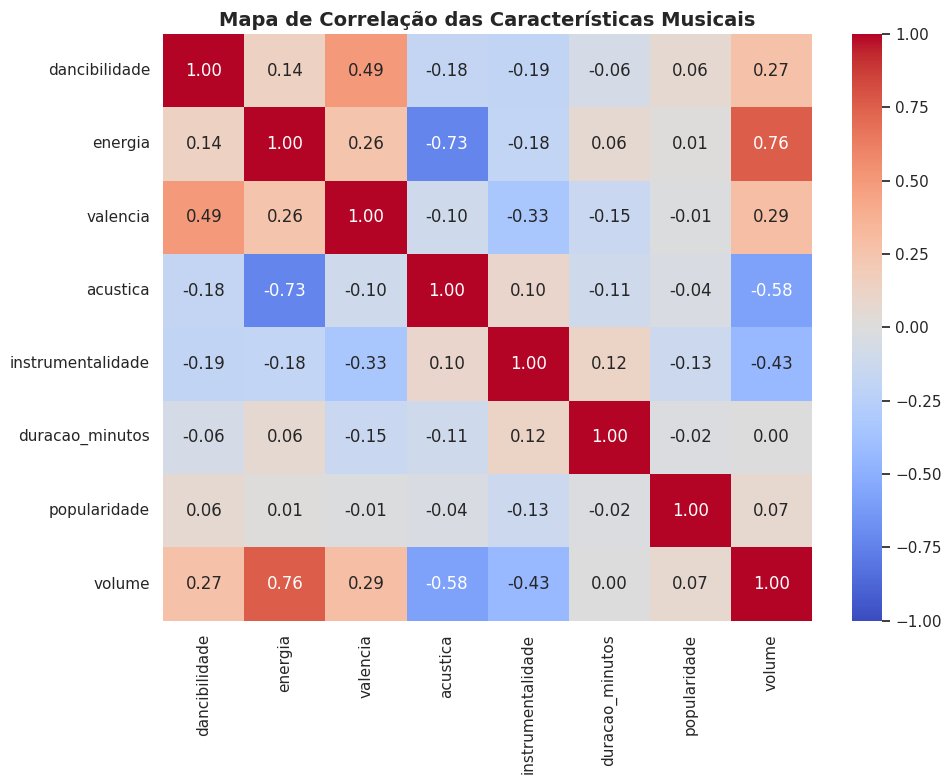

In [36]:
# ---------------------------------------------------------
# 4. GRÁFICO 2: Mapa de Calor (Correlação)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Selecionando apenas as variáveis traduzidas de interesse
colunas_analise = ['dancibilidade', 'energia', 'valencia', 'acustica', 'instrumentalidade', 'duracao_minutos', 'popularidade', 'volume']
matriz_corr = df[colunas_analise].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)
plt.title('Mapa de Correlação das Características Musicais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

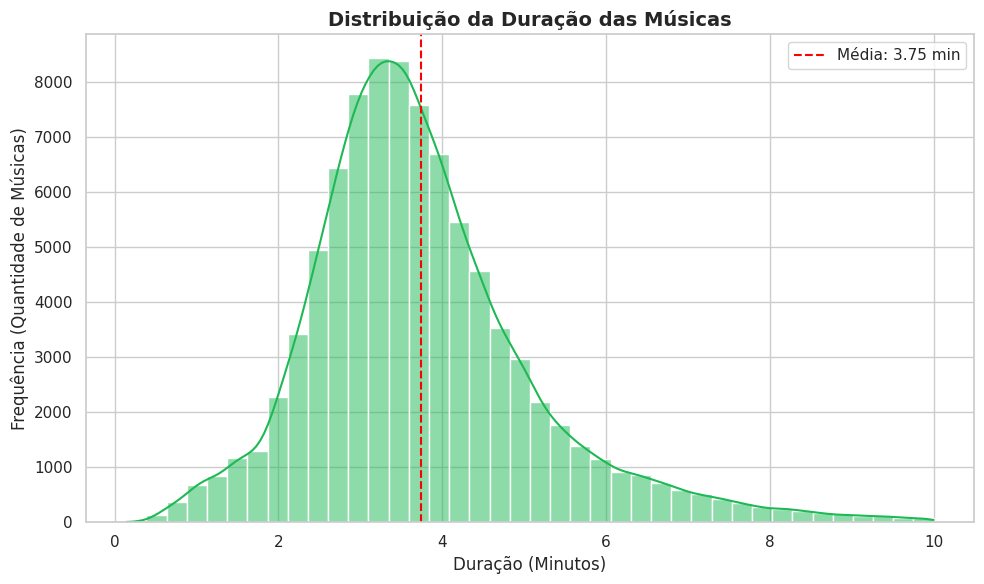

In [ ]:
# ---------------------------------------------------------
# 5. GRÁFICO 3: Distribuição da Duração
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
df_filtrado = df[df['duracao_minutos'] < 10]

sns.histplot(data=df_filtrado, x='duracao_minutos', bins=40, kde=True, color='#1DB954')

plt.title('Distribuição da Duração das Músicas no Spotify', fontsize=14, fontweight='bold')
plt.xlabel('Duração (Minutos)', fontsize=12)
plt.ylabel('Quantidade de Músicas', fontsize=12)

media_duracao = df_filtrado['duracao_minutos'].mean()
plt.axvline(media_duracao, color='red', linestyle='--', label=f'Média: {media_duracao:.2f} min')
plt.legend()

plt.tight_layout()
plt.show()